# Plant Disease Classification + Grad-CAM IoU Evaluation

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from pathlib import Path

BASE_DIR     = Path('E:/quant/plant_disease')
PLANTVILLAGE = BASE_DIR / 'plantvillage dataset' / 'color'    
BBOX_DATASET = BASE_DIR / 'My First Project.v1i.yolov8'   
OUTPUT_DIR   = BASE_DIR / 'outputs'
MODEL_DIR    = BASE_DIR / 'models'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR    :', BASE_DIR)
print('PlantVillage:', PLANTVILLAGE)
print('BBox dataset:', BBOX_DATASET)
print('Outputs     :', OUTPUT_DIR)
print('Models      :', MODEL_DIR)

BASE_DIR    : E:\quant\plant_disease
PlantVillage: E:\quant\plant_disease\plantvillage dataset\color
BBox dataset: E:\quant\plant_disease\My First Project.v1i.yolov8
Outputs     : E:\quant\plant_disease\outputs
Models      : E:\quant\plant_disease\models


In [2]:
import subprocess, sys
for pkg in ['grad-cam', 'opencv-python', 'scikit-learn', 'seaborn', 'matplotlib', 'Pillow']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Dependencies installed.')

Dependencies installed.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import time
import csv
import shutil
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
print('Common imports done.')

Common imports done.


## PRE-PROCESSING PlantVillage

In [4]:
def remove_background_opencv(img_np):
   
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l_channel = lab[:, :, 1]

    _, mask = cv2.threshold(l_channel, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    mask_3ch = cv2.merge([mask, mask, mask])
    result = cv2.bitwise_and(img_np, mask_3ch)
    return result


def preprocess_plantvillage(src_dir, dst_dir, img_size=224, max_per_class=None):
    
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    if dst_dir.exists() and len(list(dst_dir.rglob('*.jpg'))) > 1000:
        print(f'Pre-processed dataset sudah ada di {dst_dir}, skip.')
        return dst_dir

    print(f'Pre-processing PlantVillage -> {dst_dir} ...')
    total, processed = 0, 0

    for class_dir in sorted(src_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        out_class = dst_dir / class_dir.name
        out_class.mkdir(parents=True, exist_ok=True)

        img_files = list(class_dir.glob('*.jpg')) + \
                    list(class_dir.glob('*.jpeg')) + \
                    list(class_dir.glob('*.JPG')) + \
                    list(class_dir.glob('*.png'))

        if max_per_class:
            img_files = img_files[:max_per_class]

        for img_path in img_files:
            try:
                img = np.array(Image.open(img_path).convert('RGB'))
                img = cv2.resize(img, (img_size, img_size))
                img = remove_background_opencv(img)
                out_path = out_class / img_path.name
                Image.fromarray(img).save(str(out_path))
                processed += 1
            except Exception as e:
                pass
            total += 1

        print(f'  [{class_dir.name}] {processed}/{total} done')

    print(f'Pre-processing selesai: {processed} gambar.')
    return dst_dir


PLANTVILLAGE_PROCESSED = BASE_DIR / 'PlantVillage_processed'
PLANTVILLAGE_PROCESSED = preprocess_plantvillage(PLANTVILLAGE, PLANTVILLAGE_PROCESSED)
print('PlantVillage processed dir:', PLANTVILLAGE_PROCESSED)

Pre-processed dataset sudah ada di E:\quant\plant_disease\PlantVillage_processed, skip.
PlantVillage processed dir: E:\quant\plant_disease\PlantVillage_processed


## PRE-PROCESSING BoundingBox Dataset

In [5]:
def preprocess_bbox_dataset(bbox_root, img_size=224):

    bbox_root = Path(bbox_root)

    for subfolder in ['train', 'test', 'valid', '']:
        img_dir = bbox_root / subfolder / 'images' if subfolder else bbox_root / 'images'
        lbl_dir = bbox_root / subfolder / 'labels' if subfolder else bbox_root / 'labels'
        if img_dir.exists():
            break

    out_root  = bbox_root.parent / 'BoundingBox_processed'
    out_imgs  = out_root / 'images'
    out_lbls  = out_root / 'labels'
    out_imgs.mkdir(parents=True, exist_ok=True)
    out_lbls.mkdir(parents=True, exist_ok=True)

    if len(list(out_imgs.glob('*.jpg'))) > 100:
        print(f'BoundingBox processed sudah ada, skip.')
        return out_imgs, out_lbls

    img_files = list(img_dir.glob('*.jpg')) + \
                list(img_dir.glob('*.jpeg')) + \
                list(img_dir.glob('*.png'))

    print(f'Pre-processing {len(img_files)} BoundingBox images...')
    processed = 0

    for img_path in img_files:
        try:
            img = np.array(Image.open(img_path).convert('RGB'))
            img = cv2.resize(img, (img_size, img_size))
            img = remove_background_opencv(img)
            Image.fromarray(img).save(str(out_imgs / img_path.name))

            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if lbl_path.exists():
                shutil.copy(str(lbl_path), str(out_lbls / lbl_path.name))

            processed += 1
        except Exception as e:
            pass

    print(f'BoundingBox pre-processing selesai: {processed} gambar.')
    return out_imgs, out_lbls


BBOX_IMAGES, BBOX_LABELS = preprocess_bbox_dataset(BBOX_DATASET)
print('BBox images:', BBOX_IMAGES)
print('BBox labels:', BBOX_LABELS)

BoundingBox processed sudah ada, skip.
BBox images: E:\quant\plant_disease\BoundingBox_processed\images
BBox labels: E:\quant\plant_disease\BoundingBox_processed\labels


In [6]:
import random
from pathlib import Path

IMG_SIZE    = 224
BATCH_SIZE  = 50
EPOCHS      = 10
LR          = 0.001
DROPOUT     = 0.25
NUM_CLASSES = 38
SEED        = 42

random.seed(SEED)

PLANTVILLAGE_PROCESSED = BASE_DIR / 'PlantVillage_processed'
SPLIT_DIR              = BASE_DIR / 'split'

class_dirs  = sorted([d for d in PLANTVILLAGE_PROCESSED.iterdir() if d.is_dir()])
CLASS_NAMES = [d.name for d in class_dirs]

print(f'IMG_SIZE    : {IMG_SIZE}')
print(f'BATCH_SIZE  : {BATCH_SIZE}')
print(f'NUM_CLASSES : {NUM_CLASSES}')
print(f'Classes found: {len(CLASS_NAMES)}')

IMG_SIZE    : 224
BATCH_SIZE  : 50
NUM_CLASSES : 38
Classes found: 38


## Dataset Split

In [7]:
import shutil

if SPLIT_DIR.exists():
    shutil.rmtree(str(SPLIT_DIR))
    print('Folder split lama dihapus.')
else:
    print('Folder split belum ada, akan dibuat baru.')

import random
random.seed(SEED)

all_imgs, all_labels = [], []
class_dirs   = sorted([d for d in PLANTVILLAGE_PROCESSED.iterdir() if d.is_dir()])
CLASS_NAMES  = [d.name for d in class_dirs]
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

for cls_dir in class_dirs:
    imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
    for img in imgs:
        all_imgs.append(str(img))
        all_labels.append(class_to_idx[cls_dir.name])

combined = list(zip(all_imgs, all_labels))
random.shuffle(combined)
all_imgs, all_labels = zip(*combined)

n       = len(all_imgs)
n_train = int(0.70 * n)
n_val   = int(0.20 * n)
n_test  = n - n_train - n_val

train_imgs   = all_imgs[:n_train]
train_labels = all_labels[:n_train]
val_imgs     = all_imgs[n_train:n_train+n_val]
val_labels   = all_labels[n_train:n_train+n_val]
test_imgs    = all_imgs[n_train+n_val:]
test_labels  = all_labels[n_train+n_val:]

print(f'Total: {n} | Train: {n_train} (70%) | Val: {n_val} (20%) | Test: {n_test} (10%)')
print(f'Classes: {len(CLASS_NAMES)}')

Folder split lama dihapus.
Total: 54305 | Train: 38013 (70%) | Val: 10861 (20%) | Test: 5431 (10%)
Classes: 38


In [8]:
def write_split(img_paths, labels, split_name):
    split_path = SPLIT_DIR / split_name
    for img_path, label in zip(img_paths, labels):
        cls_name = CLASS_NAMES[label]
        dst = split_path / cls_name / Path(img_path).name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(img_path, str(dst))
    print(f'{split_name}: {len(img_paths)} images written.')

write_split(train_imgs, train_labels, 'train')
write_split(val_imgs,   val_labels,   'val')
write_split(test_imgs,  test_labels,  'test')
print('Data split selesai.')

for split in ['train', 'val', 'test']:
    total = sum(1 for f in (SPLIT_DIR/split).rglob('*') if f.is_file())
    print(f'  {split}: {total} files')


train: 38013 images written.
val: 10861 images written.
test: 5431 images written.
Data split selesai.
  train: 38013 files
  val: 10861 files
  test: 5431 files


---
## PHASE 1: Train GoogleNet d DenseNet201)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.models import GoogLeNet_Weights, DenseNet201_Weights

print('PyTorch:', torch.__version__)
print('CUDA   :', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)

PyTorch: 2.6.0+cu118
CUDA   : True
Device : cuda


In [10]:
class SplitDataset(Dataset):
    def __init__(self, split_dir, transform, class_names):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        for cls_dir in sorted(Path(split_dir).iterdir()):
            if not cls_dir.is_dir(): continue
            for img_path in cls_dir.glob('*'):
                if img_path.suffix.lower() in ['.jpg','.jpeg','.png']:
                    self.samples.append((str(img_path), self.class_to_idx[cls_dir.name]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label


pt_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
pt_val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

pt_train_ds = SplitDataset(SPLIT_DIR/'train', pt_train_transform, CLASS_NAMES)
pt_val_ds   = SplitDataset(SPLIT_DIR/'val',   pt_val_transform,   CLASS_NAMES)
pt_test_ds  = SplitDataset(SPLIT_DIR/'test',  pt_val_transform,   CLASS_NAMES)

pt_train_loader = DataLoader(pt_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
pt_val_loader   = DataLoader(pt_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
pt_test_loader  = DataLoader(pt_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(pt_train_ds)} | Val: {len(pt_val_ds)} | Test: {len(pt_test_ds)}')

Train: 38013 | Val: 10861 | Test: 5431


In [11]:
def build_pt_head(in_features, num_classes=38, dropout=DROPOUT):
    return nn.Sequential(
        nn.Linear(in_features, 126),  nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(126, 256),          nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(256, 512),          nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(512, 1000),         nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(1000, num_classes)
    )

class GoogleNetWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model

    def forward(self, x):
        out = self.model(x)
        return out.logits if hasattr(out, 'logits') else out

class GoogleNetForGradCAM(torch.nn.Module):
    """Forward pass tanpa GoogLeNetOutputs namedtuple agar gradient bisa mengalir."""
    def __init__(self, wrapper):
        super().__init__()
        self._m = wrapper.model

    def forward(self, x):
        x = self._m.conv1(x)
        x = self._m.maxpool1(x)
        x = self._m.conv2(x)
        x = self._m.conv3(x)
        x = self._m.maxpool2(x)
        x = self._m.inception3a(x)
        x = self._m.inception3b(x)
        x = self._m.maxpool3(x)
        x = self._m.inception4a(x)
        x = self._m.inception4b(x)
        x = self._m.inception4c(x)
        x = self._m.inception4d(x)
        x = self._m.inception4e(x)
        x = self._m.maxpool4(x)
        x = self._m.inception5a(x)
        x = self._m.inception5b(x)
        x = self._m.avgpool(x)
        x = torch.flatten(x, 1)
        x = self._m.dropout(x)
        x = self._m.fc(x)
        return x

def build_googlenet():
    base = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
    base.aux1 = None
    base.aux2 = None
    for p in base.parameters():
        p.requires_grad = False
    in_f = base.fc.in_features
    base.fc = nn.Sequential(
        nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(DROPOUT),
        nn.Linear(512, NUM_CLASSES)
    )
    return GoogleNetWrapper(base)

def build_densenet201():
    m = models.densenet201(weights=DenseNet201_Weights.IMAGENET1K_V1)
    all_layers = list(m.features.children())
    freeze_n   = int(len(all_layers) * 0.75)
    for i, layer in enumerate(all_layers):  # pakai list, bukan iterator
        if i < freeze_n:
            for p in layer.parameters():
                p.requires_grad = False
    in_f = m.classifier.in_features
    m.classifier = build_pt_head(in_f, NUM_CLASSES, DROPOUT)
    return m

print('PyTorch model builders ready.')

PyTorch model builders ready.


In [12]:
def train_pt(model, model_name):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lambda epoch: 0.9 ** (epoch // 3)
    )
    history = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[]}
    best_val, patience_cnt = 0, 0
    start = time.time()

    for epoch in range(EPOCHS):
        model.train()
        tl, tc, tt = 0, 0, 0
        for imgs, lbls in pt_train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward(); optimizer.step()
            tl += loss.item(); tc += out.argmax(1).eq(lbls).sum().item(); tt += lbls.size(0)

        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for imgs, lbls in pt_val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs)
                vl += criterion(out, lbls).item()
                vc += out.argmax(1).eq(lbls).sum().item(); vt += lbls.size(0)

        t_acc = tc/tt; v_acc = vc/vt
        t_loss = tl/len(pt_train_loader); v_loss = vl/len(pt_val_loader)
        history['train_acc'].append(t_acc); history['val_acc'].append(v_acc)
        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        scheduler.step()

        print(f'[{model_name}] Epoch {epoch+1}/{EPOCHS} | '
              f'Train Acc: {t_acc:.4f} Loss: {t_loss:.4f} | '
              f'Val Acc: {v_acc:.4f} Loss: {v_loss:.4f}')

        if v_acc > best_val:
            best_val = v_acc; patience_cnt = 0
            torch.save(model.state_dict(), str(MODEL_DIR / f'{model_name}_best.pth'))
        else:
            patience_cnt += 1
            if patience_cnt >= 5:
                print(f'Early stopping at epoch {epoch+1}'); break

    elapsed = time.time() - start
    model.load_state_dict(torch.load(str(MODEL_DIR / f'{model_name}_best.pth')))
    torch.save(model.state_dict(), str(MODEL_DIR / f'{model_name}.pth'))
    print(f'{model_name} done | Best val acc: {best_val:.4f} | Time: {elapsed:.0f}s')
    return history, elapsed


def eval_pt(model, model_name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in pt_test_loader:
            out = model(imgs.to(DEVICE))
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(lbls.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    pmb  = sum(p.numel() for p in model.parameters()) * 4 / (1024**2)

    print(f'\n=== {model_name} ===')
    print(f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | Params: {pmb:.2f} MB')
    print(classification_report(y_true, y_pred,
          target_names=[c[:20] for c in CLASS_NAMES], digits=4))

    plt.figure(figsize=(20,16))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=[c[:12] for c in CLASS_NAMES],
                yticklabels=[c[:12] for c in CLASS_NAMES])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7); plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'cm_{model_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'params_mb': pmb,
            'y_true': y_true, 'y_pred': y_pred}


def plot_history_pt(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_acc'], label='Train')
    axes[0].plot(history['val_acc'],   label='Val')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['train_loss'], label='Train')
    axes[1].plot(history['val_loss'],   label='Val')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'history_{model_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return {
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss':   history['val_loss'][-1]
    }

print('PyTorch helper functions ready.')

PyTorch helper functions ready.


In [13]:
print('Testing DataLoader...')
for imgs, lbls in pt_train_loader:
    print(f'Batch shape: {imgs.shape} | Labels: {lbls.shape}')
    break
print('DataLoader OK!')

Testing DataLoader...
Batch shape: torch.Size([50, 3, 224, 224]) | Labels: torch.Size([50])
DataLoader OK!


In [14]:
print(train_pt)

<function train_pt at 0x000002EE9CAD25C0>


In [15]:
print(len(pt_train_ds))
print(len(pt_val_ds))

38013
10861


### 1B-1. GoogleNet

[GoogleNet] Epoch 1/10 | Train Acc: 0.7294 Loss: 0.9257 | Val Acc: 0.8613 Loss: 0.4456
[GoogleNet] Epoch 2/10 | Train Acc: 0.8256 Loss: 0.5410 | Val Acc: 0.8713 Loss: 0.3920
[GoogleNet] Epoch 3/10 | Train Acc: 0.8365 Loss: 0.5024 | Val Acc: 0.8892 Loss: 0.3385
[GoogleNet] Epoch 4/10 | Train Acc: 0.8507 Loss: 0.4598 | Val Acc: 0.8889 Loss: 0.3348
[GoogleNet] Epoch 5/10 | Train Acc: 0.8541 Loss: 0.4348 | Val Acc: 0.8979 Loss: 0.3024
[GoogleNet] Epoch 6/10 | Train Acc: 0.8587 Loss: 0.4298 | Val Acc: 0.8998 Loss: 0.2978
[GoogleNet] Epoch 7/10 | Train Acc: 0.8634 Loss: 0.4061 | Val Acc: 0.8981 Loss: 0.3045
[GoogleNet] Epoch 8/10 | Train Acc: 0.8672 Loss: 0.3982 | Val Acc: 0.9073 Loss: 0.2849
[GoogleNet] Epoch 9/10 | Train Acc: 0.8697 Loss: 0.3908 | Val Acc: 0.9125 Loss: 0.2671
[GoogleNet] Epoch 10/10 | Train Acc: 0.8715 Loss: 0.3853 | Val Acc: 0.9097 Loss: 0.2771
GoogleNet done | Best val acc: 0.9125 | Time: 4100s


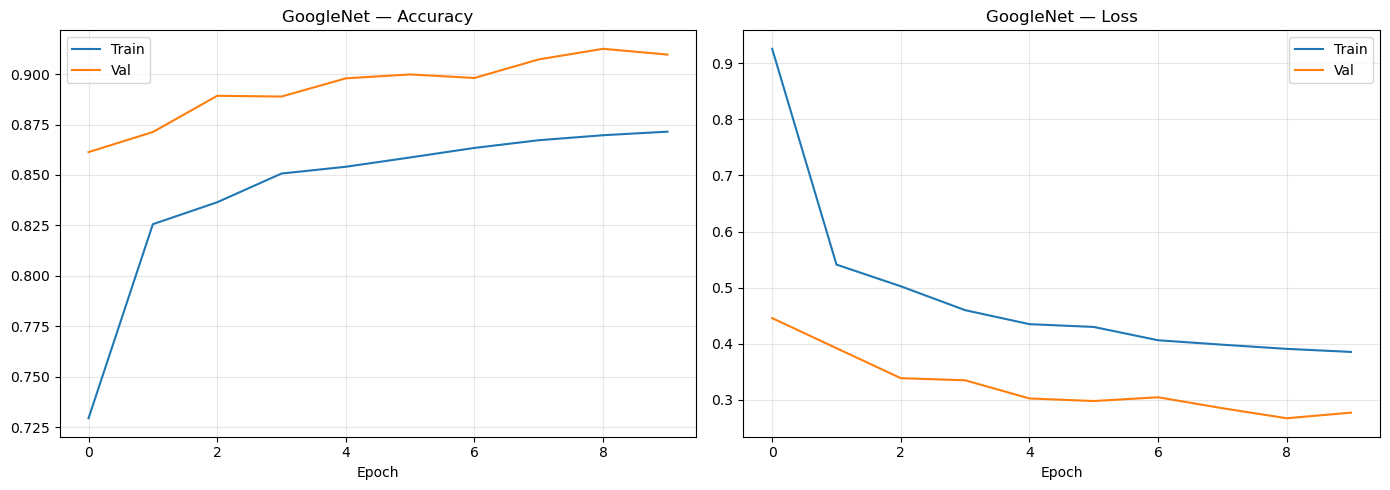


=== GoogleNet ===
Accuracy: 0.9157 | Precision: 0.9175 | Recall: 0.9157 | F1: 0.9135 | Params: 23.44 MB
                      precision    recall  f1-score   support

  Apple___Apple_scab     0.8772    0.8772    0.8772        57
   Apple___Black_rot     1.0000    0.8444    0.9157        45
Apple___Cedar_apple_     0.9524    0.8696    0.9091        23
     Apple___healthy     0.9539    0.9416    0.9477       154
 Blueberry___healthy     0.9868    0.9677    0.9772       155
Cherry_(including_so     0.9789    0.9894    0.9841        94
Cherry_(including_so     0.9741    0.9826    0.9784       115
Corn_(maize)___Cerco     0.8364    0.7931    0.8142        58
Corn_(maize)___Commo     0.8730    0.9649    0.9167       114
Corn_(maize)___healt     0.9919    0.9762    0.9840       126
Corn_(maize)___North     0.8462    0.7624    0.8021       101
   Grape___Black_rot     0.9541    0.9369    0.9455       111
Grape___Esca_(Black_     0.9211    0.9722    0.9459       108
     Grape___healthy     1

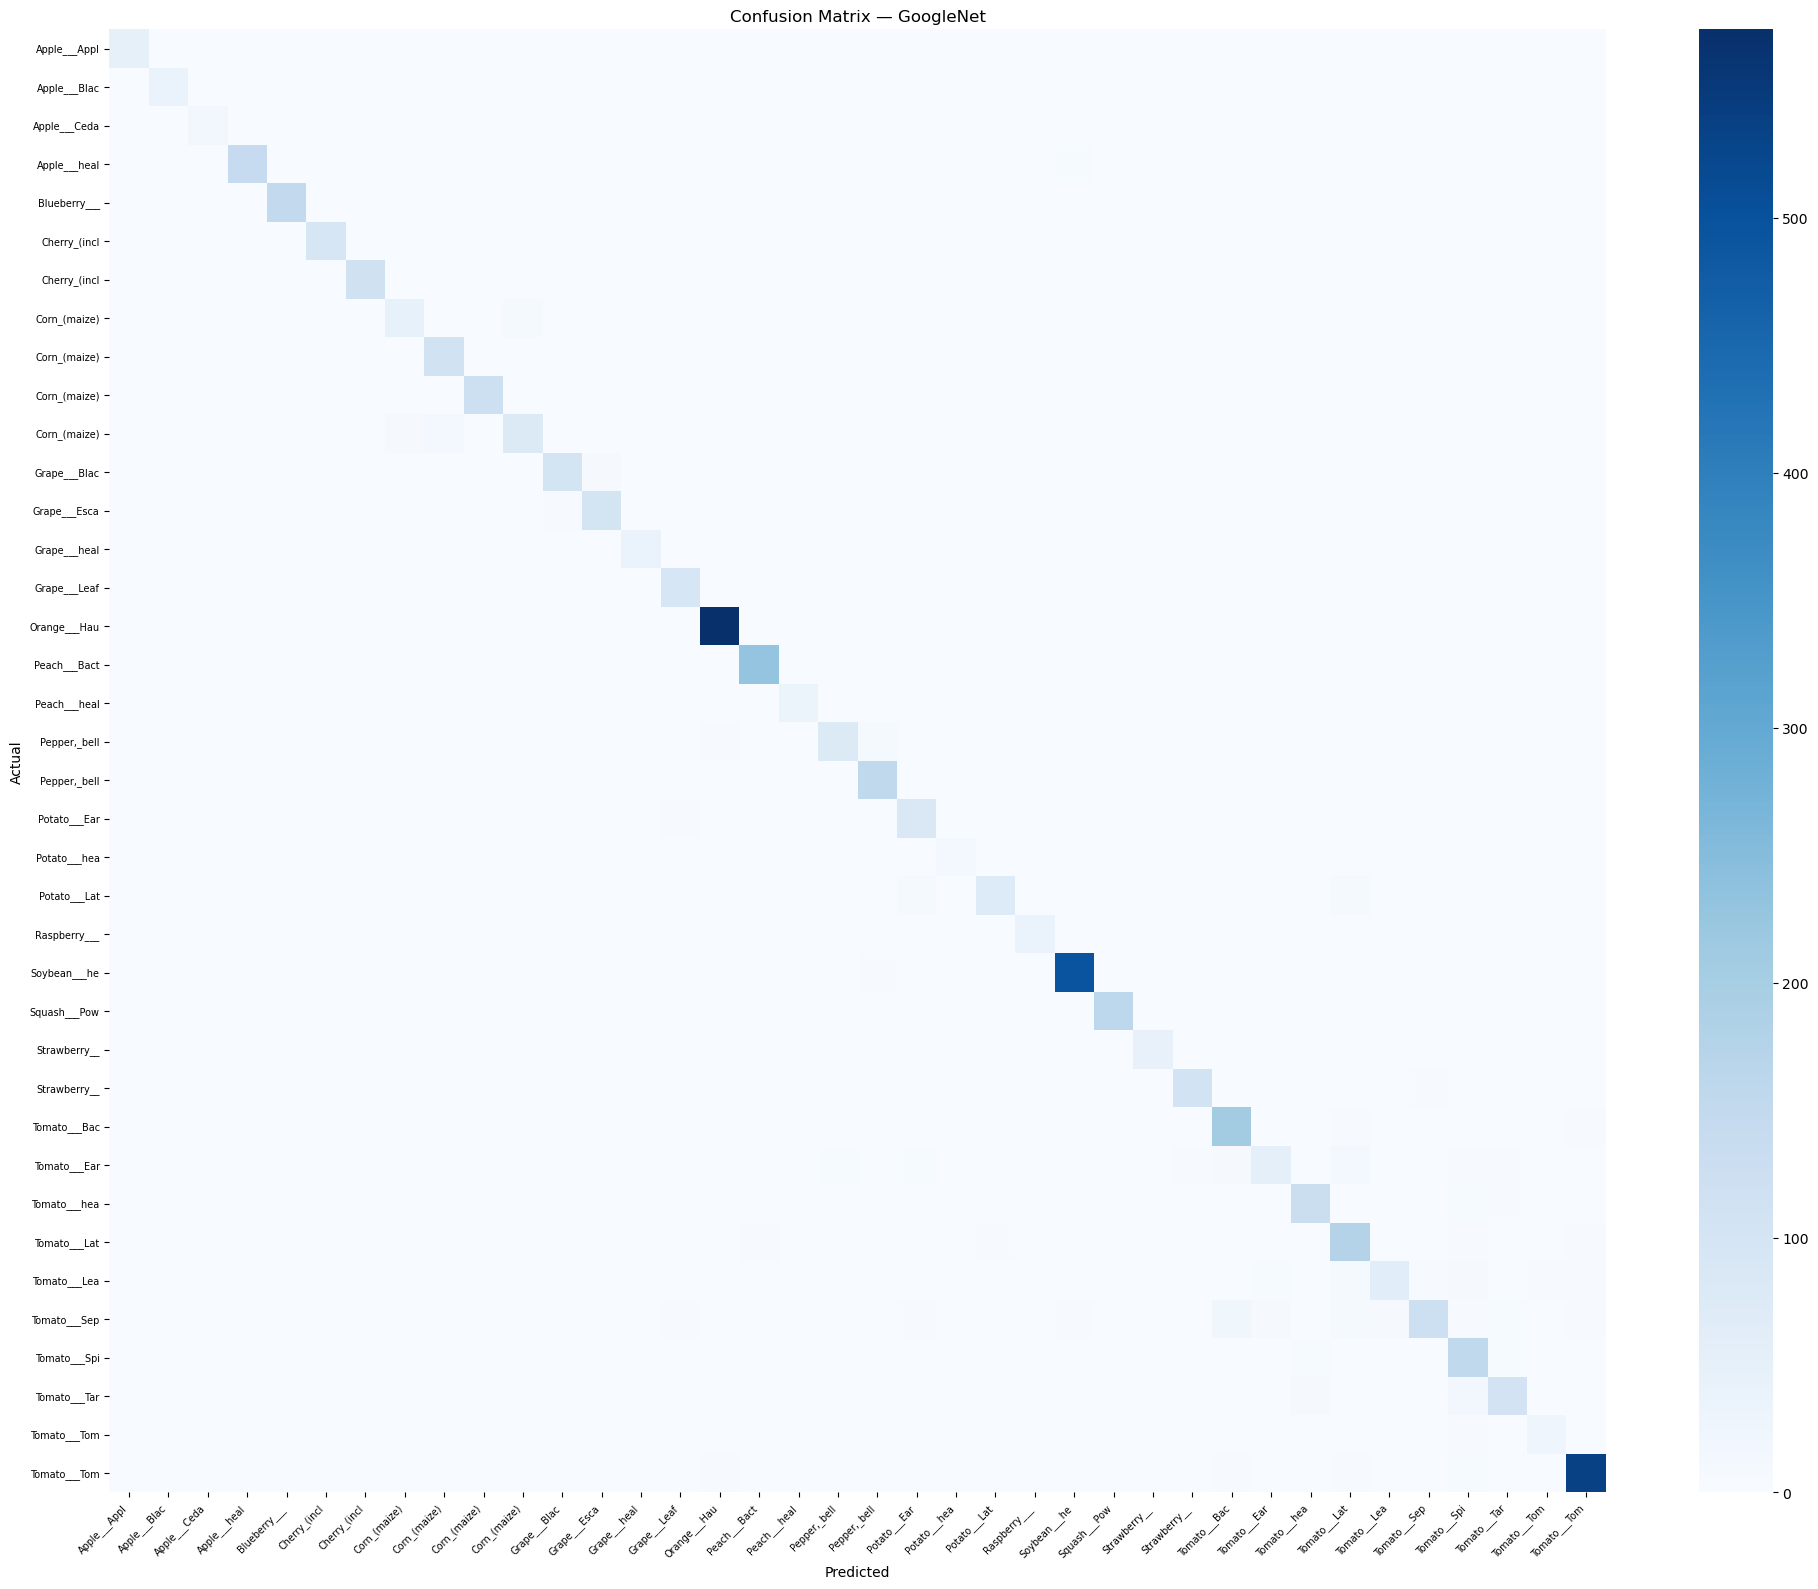

In [18]:
model_googlenet = build_googlenet()
history_googlenet, time_googlenet = train_pt(model_googlenet, 'GoogleNet')
loss_googlenet = plot_history_pt(history_googlenet, 'GoogleNet')
results_googlenet = eval_pt(model_googlenet, 'GoogleNet')
results_googlenet.update({'exec_time': time_googlenet, **loss_googlenet})

### 1B-2. DenseNet201

[DenseNet201] Epoch 1/10 | Train Acc: 0.6294 Loss: 1.1506 | Val Acc: 0.8459 Loss: 0.4469
[DenseNet201] Epoch 2/10 | Train Acc: 0.8645 Loss: 0.4281 | Val Acc: 0.9394 Loss: 0.1922
[DenseNet201] Epoch 3/10 | Train Acc: 0.9141 Loss: 0.2931 | Val Acc: 0.9505 Loss: 0.1843
[DenseNet201] Epoch 4/10 | Train Acc: 0.9365 Loss: 0.2214 | Val Acc: 0.9605 Loss: 0.1370
[DenseNet201] Epoch 5/10 | Train Acc: 0.9460 Loss: 0.1937 | Val Acc: 0.9719 Loss: 0.0986
[DenseNet201] Epoch 6/10 | Train Acc: 0.9505 Loss: 0.1776 | Val Acc: 0.9739 Loss: 0.0968
[DenseNet201] Epoch 7/10 | Train Acc: 0.9593 Loss: 0.1481 | Val Acc: 0.9765 Loss: 0.0815
[DenseNet201] Epoch 8/10 | Train Acc: 0.9637 Loss: 0.1323 | Val Acc: 0.9762 Loss: 0.0828
[DenseNet201] Epoch 9/10 | Train Acc: 0.9647 Loss: 0.1266 | Val Acc: 0.9759 Loss: 0.0901
[DenseNet201] Epoch 10/10 | Train Acc: 0.9680 Loss: 0.1235 | Val Acc: 0.9774 Loss: 0.0860
DenseNet201 done | Best val acc: 0.9774 | Time: 5811s


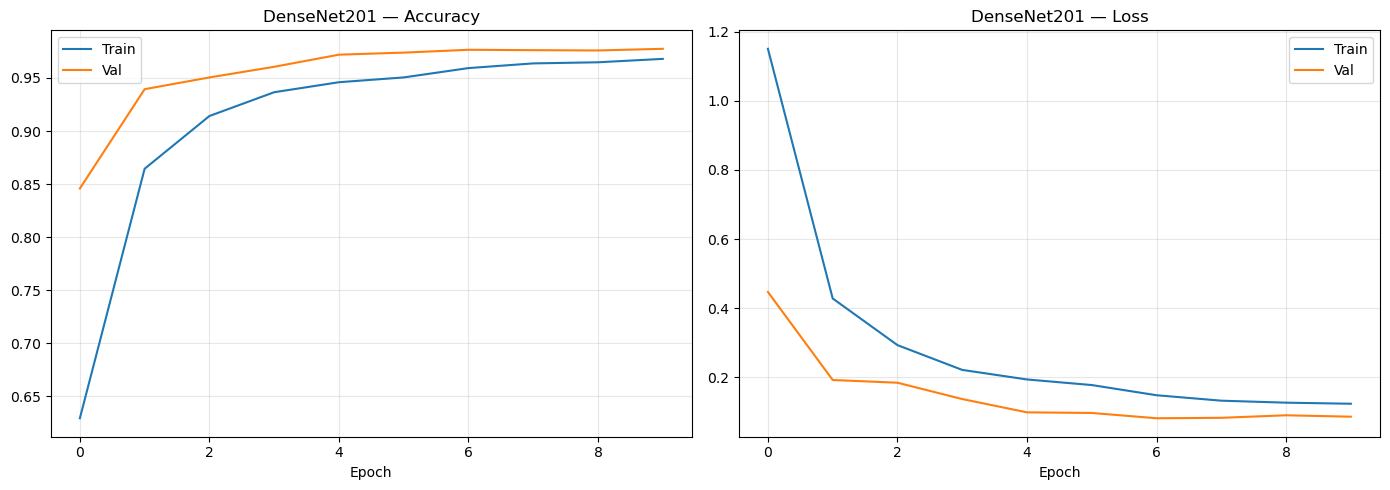


=== DenseNet201 ===
Accuracy: 0.9781 | Precision: 0.9803 | Recall: 0.9781 | F1: 0.9780 | Params: 72.67 MB
                      precision    recall  f1-score   support

  Apple___Apple_scab     1.0000    0.9825    0.9912        57
   Apple___Black_rot     1.0000    1.0000    1.0000        45
Apple___Cedar_apple_     1.0000    1.0000    1.0000        23
     Apple___healthy     1.0000    0.9805    0.9902       154
 Blueberry___healthy     0.9936    1.0000    0.9968       155
Cherry_(including_so     1.0000    1.0000    1.0000        94
Cherry_(including_so     0.9914    1.0000    0.9957       115
Corn_(maize)___Cerco     0.6517    1.0000    0.7891        58
Corn_(maize)___Commo     0.9912    0.9912    0.9912       114
Corn_(maize)___healt     0.9921    1.0000    0.9960       126
Corn_(maize)___North     1.0000    0.6634    0.7976       101
   Grape___Black_rot     0.9737    1.0000    0.9867       111
Grape___Esca_(Black_     1.0000    0.9630    0.9811       108
     Grape___healthy    

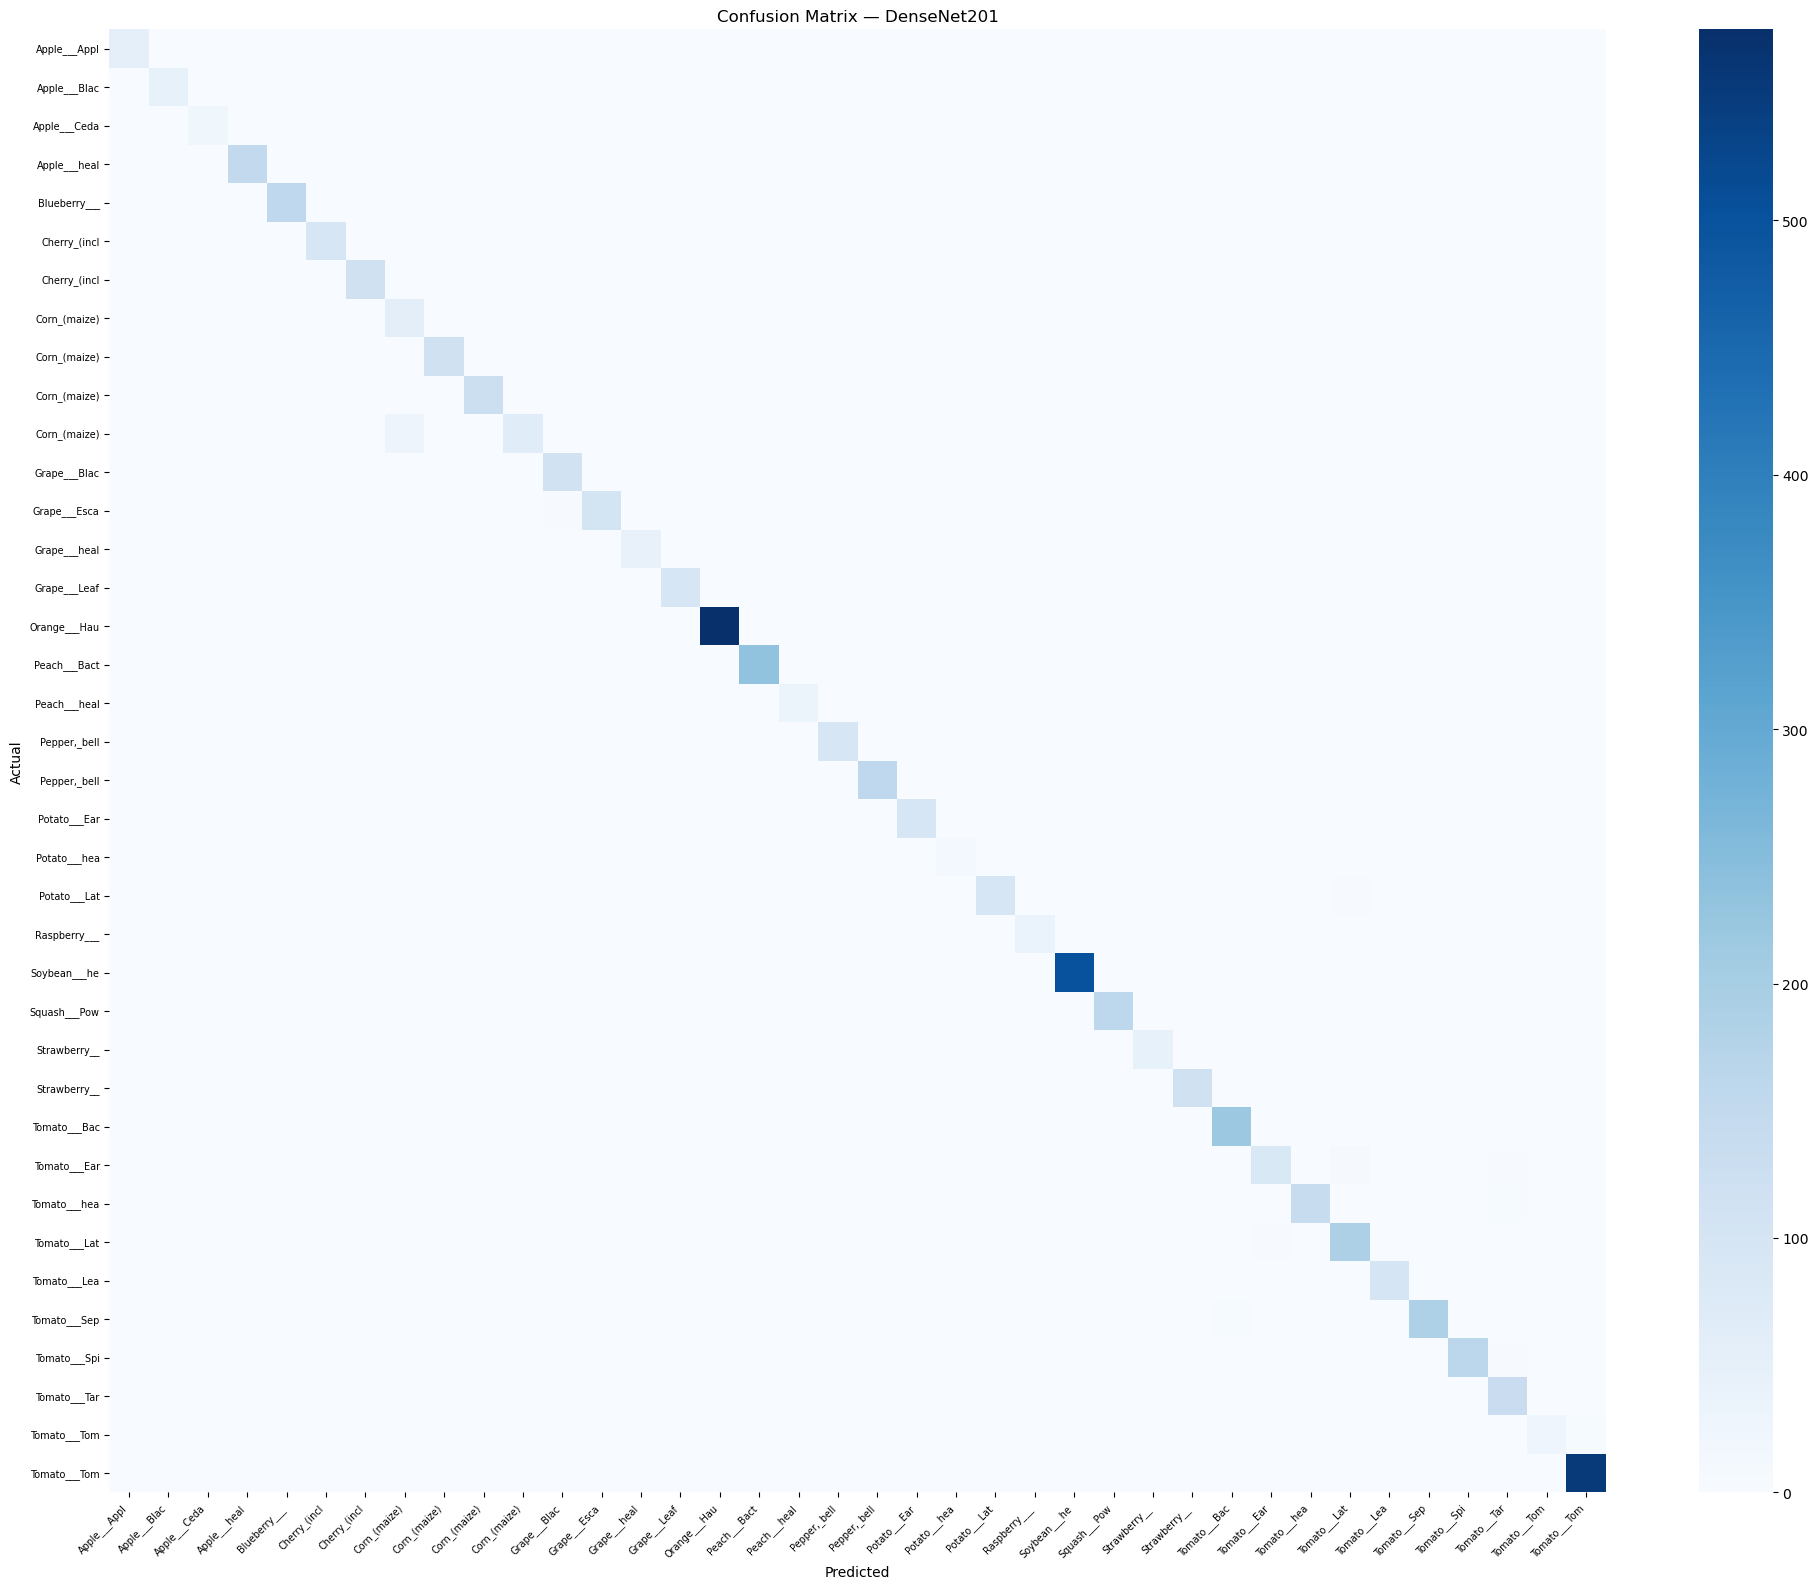

In [19]:
model_densenet201 = build_densenet201()
history_densenet201, time_densenet201 = train_pt(model_densenet201, 'DenseNet201')
loss_densenet201 = plot_history_pt(history_densenet201, 'DenseNet201')
results_densenet201 = eval_pt(model_densenet201, 'DenseNet201')
results_densenet201.update({'exec_time': time_densenet201, **loss_densenet201})

In [20]:
print('Training selesai. Hyperparameter sesuai Salka et al. (2025):')
print(f'  LR      : {LR}')
print(f'  EPOCHS  : {EPOCHS}')
print(f'  BATCH   : {BATCH_SIZE}')
print(f'  DROPOUT : {DROPOUT}')


Training selesai. Hyperparameter sesuai Salka et al. (2025):
  LR      : 0.001
  EPOCHS  : 10
  BATCH   : 50
  DROPOUT : 0.25


---
## PHASE 1 SUMMARY


Model              Accuracy   Val Loss   Recall       F1  Precision  Params(MB)   Time(s)
GoogleNet            0.9157     0.2771   0.9157   0.9135     0.9175       23.44      4100
DenseNet201          0.9781     0.0860   0.9781   0.9780     0.9803       72.67      5811


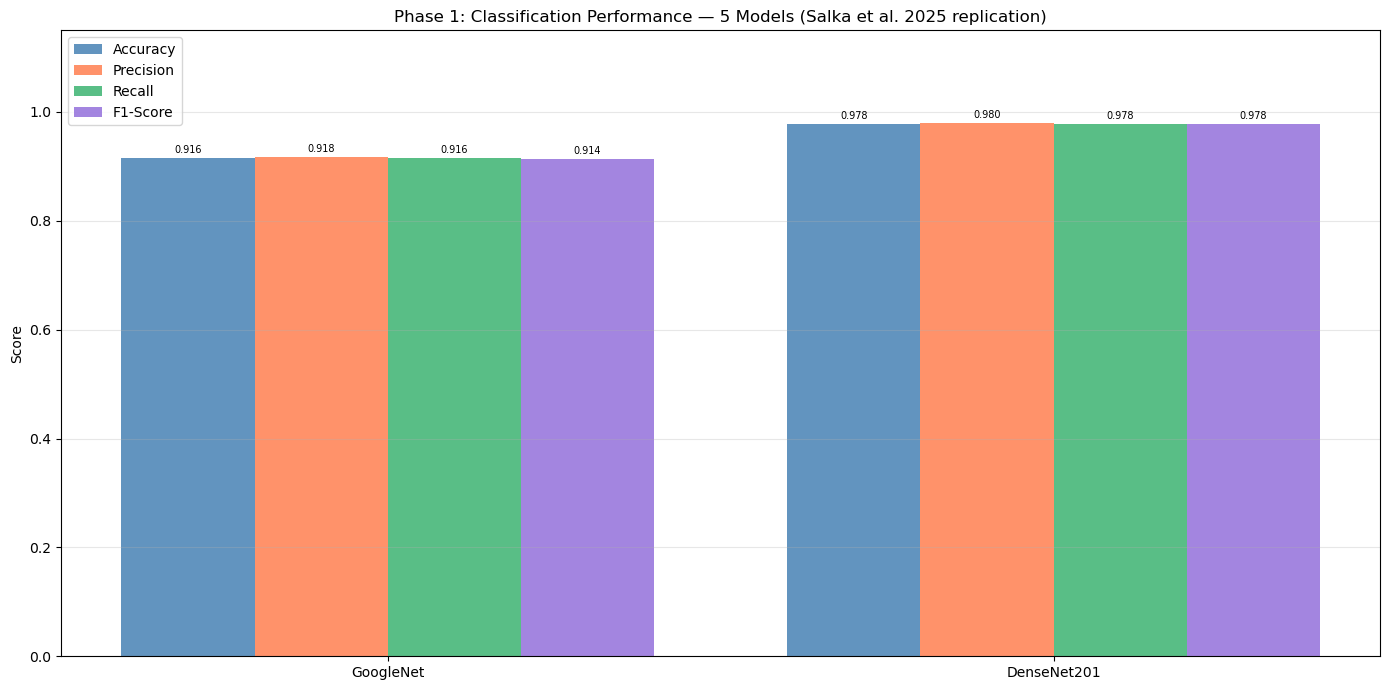

In [21]:
all_results = [
    results_googlenet, results_densenet201
]

print('\n' + '='*100)
print(f'{"Model":<16} {"Accuracy":>10} {"Val Loss":>10} {"Recall":>8} '
      f'{"F1":>8} {"Precision":>10} {"Params(MB)":>11} {"Time(s)":>9}')
print('='*100)
for r in all_results:
    print(f'{r["model"]:<16} {r["accuracy"]:>10.4f} '
          f'{r.get("final_val_loss", float("nan")):>10.4f} '
          f'{r["recall"]:>8.4f} {r["f1"]:>8.4f} '
          f'{r["precision"]:>10.4f} {r["params_mb"]:>11.2f} '
          f'{r["exec_time"]:>9.0f}')
print('='*100)

model_names = [r['model'] for r in all_results]
x = np.arange(len(model_names))
width = 0.2
metrics_list = [('accuracy','Accuracy'), ('precision','Precision'),
                ('recall','Recall'), ('f1','F1-Score')]
colors = ['steelblue','coral','mediumseagreen','mediumpurple']

fig, ax = plt.subplots(figsize=(14, 7))
for i, ((key, label), color) in enumerate(zip(metrics_list, colors)):
    vals = [r[key] for r in all_results]
    bars = ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width*1.5); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Phase 1: Classification Performance — 5 Models (Salka et al. 2025 replication)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'phase1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## PHASE 2: Grad-CAM + IoU Evaluation

In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch.nn.functional as F
print('Grad-CAM imports done.')

Grad-CAM imports done.


In [23]:
def load_yolo_bbox(img_path, label_dir):
    label_path = Path(label_dir) / (Path(img_path).stem + '.txt')
    bboxes = []
    if label_path.exists():
        for line in open(label_path):
            parts = line.strip().split()
            if len(parts) >= 5:
                _, xc, yc, w, h = map(float, parts[:5])
                bboxes.append([xc, yc, w, h])
    return bboxes

def yolo_to_pixel(bbox, img_w=224, img_h=224):
    xc, yc, w, h = bbox
    x1 = max(0, int((xc - w/2) * img_w))
    y1 = max(0, int((yc - h/2) * img_h))
    x2 = min(img_w, int((xc + w/2) * img_w))
    y2 = min(img_h, int((yc + h/2) * img_h))
    return x1, y1, x2, y2

def compute_iou(heatmap, bbox_pixel, threshold=0.5):
    cam_mask = (heatmap >= threshold).astype(np.uint8)
    x1, y1, x2, y2 = bbox_pixel
    gt_mask = np.zeros_like(cam_mask)
    gt_mask[y1:y2, x1:x2] = 1
    inter = np.logical_and(cam_mask, gt_mask).sum()
    union = np.logical_or(cam_mask, gt_mask).sum()
    return float(inter) / float(union) if union > 0 else 0.0

class ManualGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   
        cam = (weights * self.activations).sum(dim=1, keepdim=True) 
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, class_idx

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

print('Grad-CAM helpers ready.')


Grad-CAM helpers ready.


In [24]:
bbox_img_paths = sorted(
    list(BBOX_IMAGES.glob('*.jpg')) +
    list(BBOX_IMAGES.glob('*.jpeg')) +
    list(BBOX_IMAGES.glob('*.png'))
)
print(f'BoundingBox images found: {len(bbox_img_paths)}')

bbox_img_paths = [p for p in bbox_img_paths
                  if (BBOX_LABELS / (p.stem + '.txt')).exists()]
print(f'Images with labels: {len(bbox_img_paths)}')

N_EVAL = len(bbox_img_paths)
eval_paths = bbox_img_paths[:N_EVAL]
print(f'Evaluating on {N_EVAL} images.')

BoundingBox images found: 1500
Images with labels: 1500
Evaluating on 1500 images.


In [25]:
gradcam_googlenet = ManualGradCAM(model_googlenet, model_googlenet.model.inception5b)
gradcam_densenet  = ManualGradCAM(model_densenet201, model_densenet201.features.denseblock4)

manual_cams = {
    'GoogleNet':   gradcam_googlenet,
    'DenseNet201': gradcam_densenet
}

# Test dulu
print('Testing Grad-CAM...')
test_img = next(iter(pt_val_loader))[0][:1].to(DEVICE)

cam_g, pred_g = gradcam_googlenet(test_img)
print(f'GoogleNet OK -> cam shape: {cam_g.shape}, pred: {pred_g}')

cam_d, pred_d = gradcam_densenet(test_img)
print(f'DenseNet201 OK -> cam shape: {cam_d.shape}, pred: {pred_d}')


Testing Grad-CAM...
GoogleNet OK -> cam shape: (224, 224), pred: 0
DenseNet201 OK -> cam shape: (224, 224), pred: 0


In [26]:
iou_results = {n: [] for n in ['GoogleNet', 'DenseNet201']}

print(f'Running Phase 2 IoU evaluation on {N_EVAL} images...')
for idx, img_path in enumerate(eval_paths):
    bboxes = load_yolo_bbox(img_path, BBOX_LABELS)
    if not bboxes:
        continue
    if (idx + 1) % 50 == 0:
        print(f'  {idx+1}/{N_EVAL} processed...')
    img_np = np.array(Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
    img_pt = pt_val_transform(Image.fromarray(img_np)).unsqueeze(0).to(DEVICE)

    for model_name, cam_obj in manual_cams.items():
        try:
            grayscale, _ = cam_obj(img_pt)
            for bbox in bboxes:
                iou_results[model_name].append(
                    compute_iou(grayscale, yolo_to_pixel(bbox))
                )
        except Exception as e:
            print(f'{model_name}: {e}')

print('Phase 2 IoU evaluation complete.')

Running Phase 2 IoU evaluation on 1500 images...
  50/1500 processed...
  100/1500 processed...
  150/1500 processed...
  200/1500 processed...
  250/1500 processed...
  300/1500 processed...
  350/1500 processed...
  400/1500 processed...
  450/1500 processed...
  500/1500 processed...
  550/1500 processed...
  600/1500 processed...
  650/1500 processed...
  700/1500 processed...
  750/1500 processed...
  800/1500 processed...
  850/1500 processed...
  900/1500 processed...
  950/1500 processed...
  1000/1500 processed...
  1050/1500 processed...
  1100/1500 processed...
  1150/1500 processed...
  1200/1500 processed...
  1250/1500 processed...
  1300/1500 processed...
  1350/1500 processed...
  1400/1500 processed...
  1450/1500 processed...
  1500/1500 processed...
Phase 2 IoU evaluation complete.


In [27]:
iou_summary = {}
print('\n' + '='*65)
print(f'{"Model":<16} {"Mean IoU":>10} {"Median":>10} {"Std":>8} {"N":>6}')
print('='*65)
for name, ious in iou_results.items():
    if ious:
        arr = np.array(ious)
        iou_summary[name] = {'mean': arr.mean(), 'median': np.median(arr),
                              'std': arr.std(), 'n': len(arr)}
        print(f'{name:<16} {arr.mean():>10.4f} {np.median(arr):>10.4f} '
              f'{arr.std():>8.4f} {len(arr):>6}')
print('='*65)


Model              Mean IoU     Median      Std      N
GoogleNet            0.1805     0.1516   0.1587   9276
DenseNet201          0.1573     0.1078   0.1649   9276


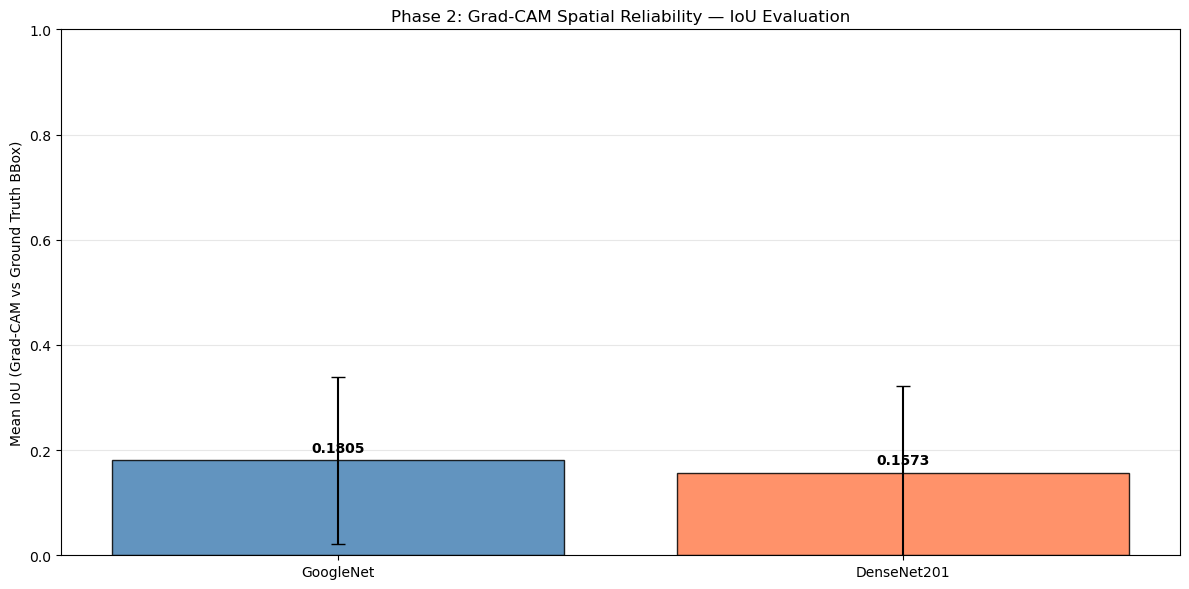

In [28]:
valid = list(iou_summary.keys())
means = [iou_summary[m]['mean'] for m in valid]
stds  = [iou_summary[m]['std']  for m in valid]
colors5 = ['steelblue','coral','mediumseagreen','mediumpurple','goldenrod']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(valid, means, yerr=stds, capsize=5,
              color=colors5[:len(valid)], alpha=0.85, edgecolor='black')
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean IoU (Grad-CAM vs Ground Truth BBox)')
ax.set_title('Phase 2: Grad-CAM Spatial Reliability — IoU Evaluation')
ax.set_ylim(0, 1.0); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'phase2_iou_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_22628\3334542349.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=valid, patch_artist=True, notch=True)


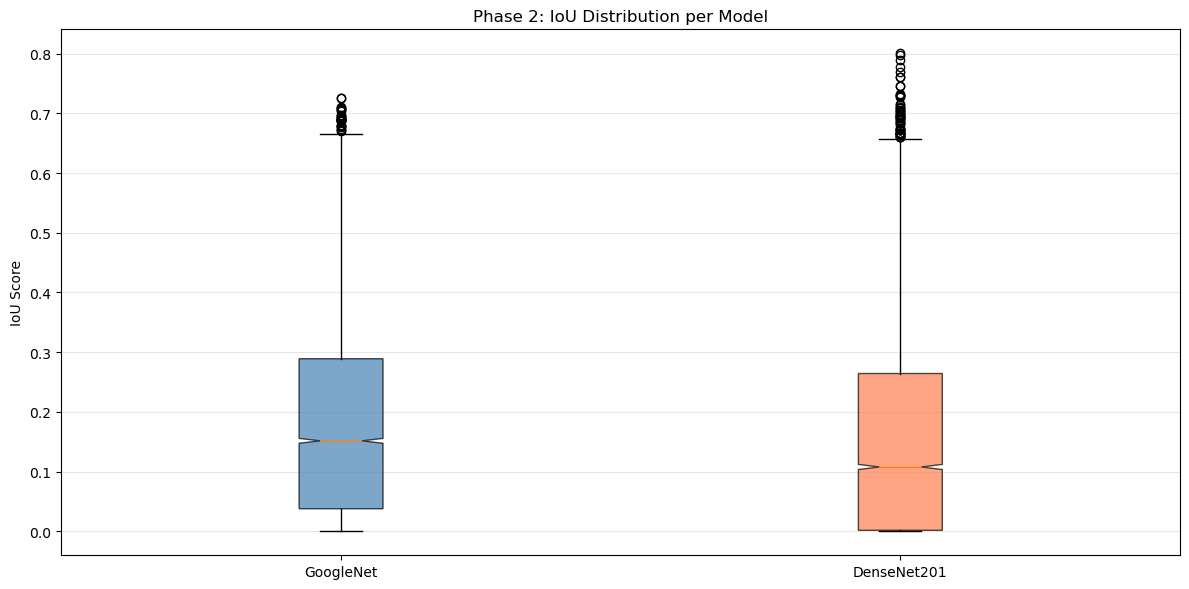

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
data_bp = [iou_results[m] for m in valid]
bp = ax.boxplot(data_bp, labels=valid, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors5):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('IoU Score')
ax.set_title('Phase 2: IoU Distribution per Model')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'phase2_iou_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

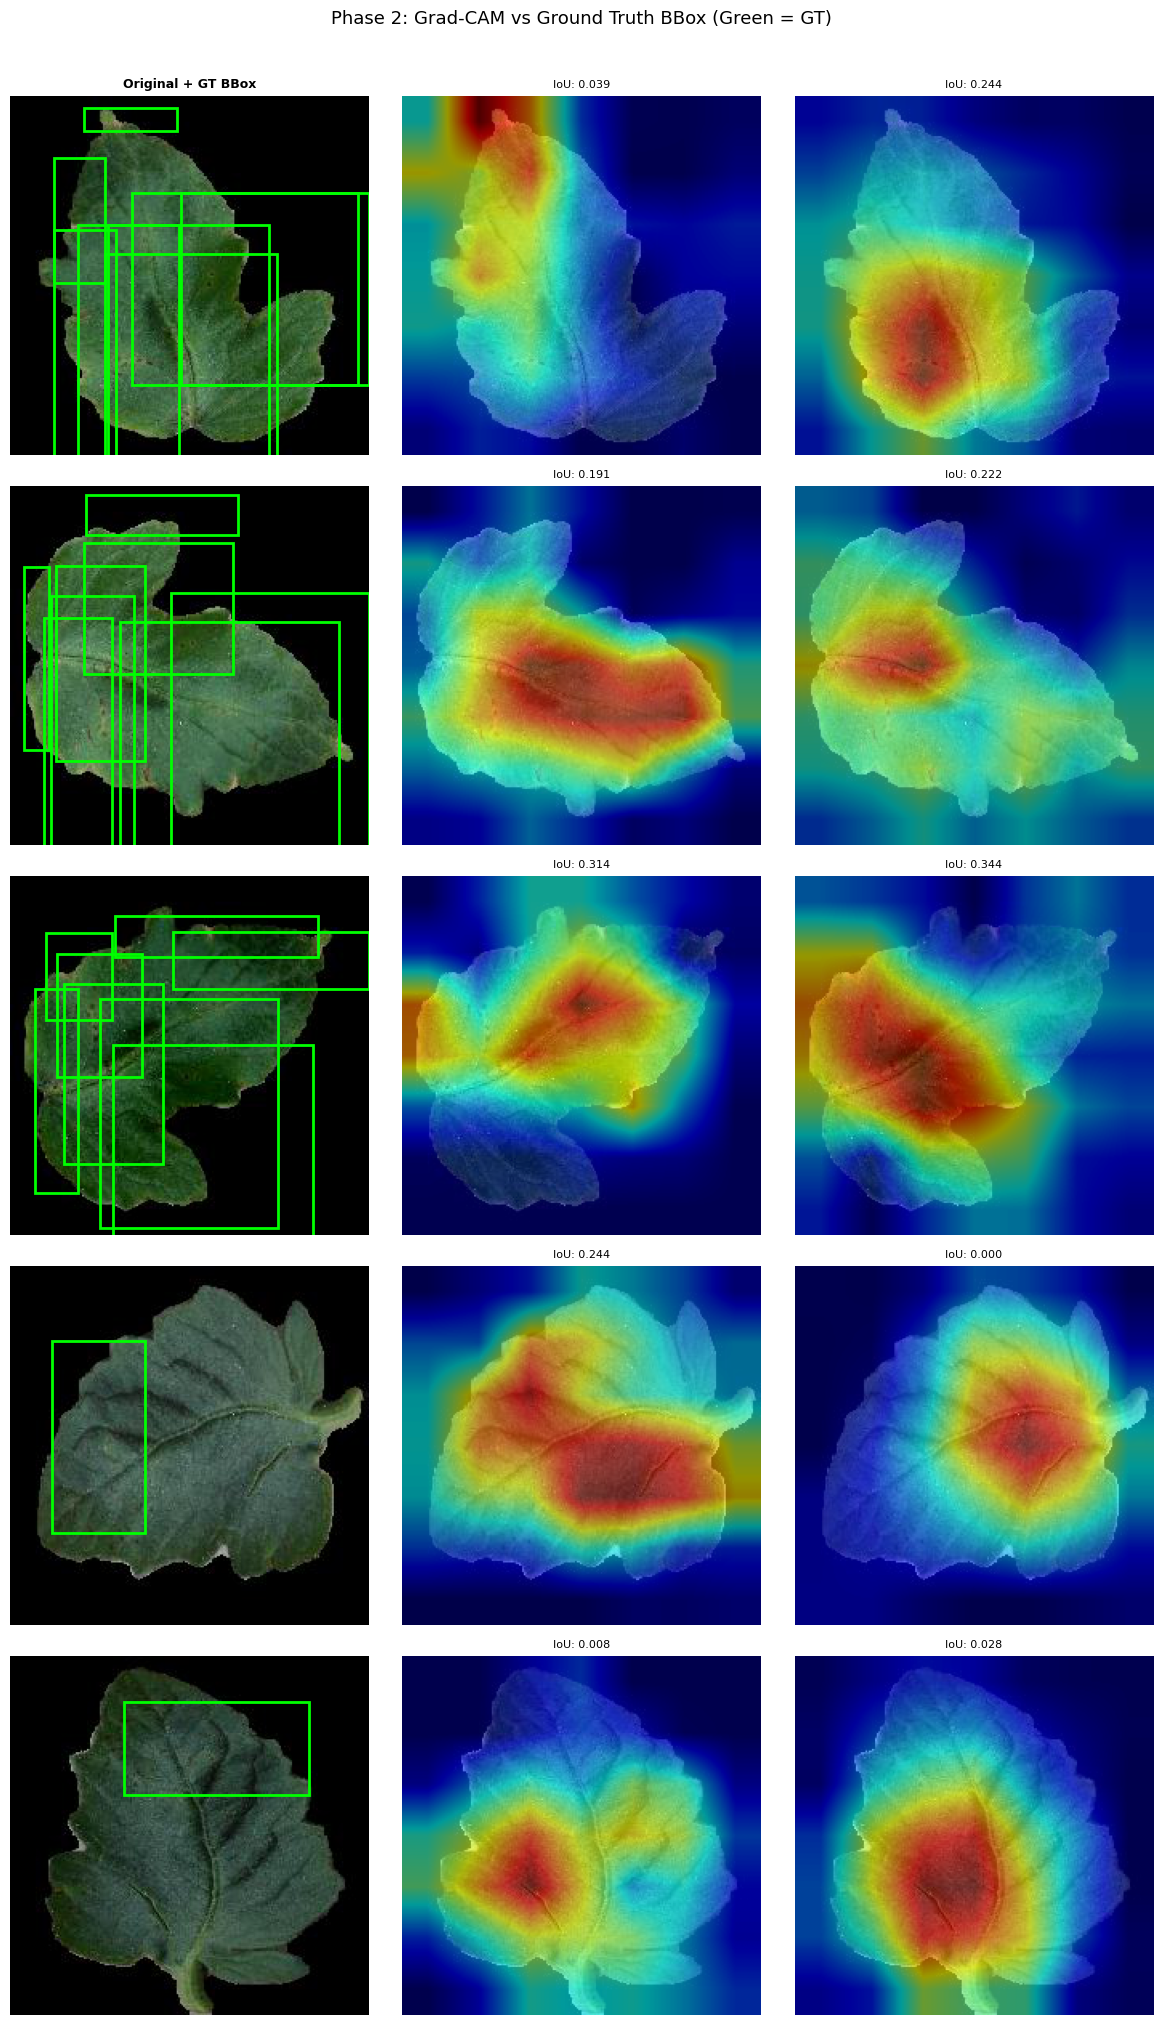

In [30]:
sample_paths = [p for p in eval_paths if load_yolo_bbox(p, BBOX_LABELS)][:5]
fig, axes = plt.subplots(len(sample_paths), 3, figsize=(12, len(sample_paths)*4))
col_titles = ['Original + GT BBox', 'GoogleNet', 'DenseNet201']

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=9, fontweight='bold')

for row, img_path in enumerate(sample_paths):
    bboxes  = load_yolo_bbox(img_path, BBOX_LABELS)
    img_np  = np.array(Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
    img_vis = img_np.astype(np.float32) / 255.0
    img_pt  = pt_val_transform(Image.fromarray(img_np)).unsqueeze(0).to(DEVICE)

    axes[row, 0].imshow(img_np)
    for bbox in bboxes:
        x1, y1, x2, y2 = yolo_to_pixel(bbox)
        axes[row, 0].add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1, lw=2, edgecolor='lime', facecolor='none'))
    axes[row, 0].axis('off')

    for col, (mname, cam_obj) in enumerate(manual_cams.items(), start=1):
        try:
            grayscale, _ = cam_obj(img_pt)
            overlay = show_cam_on_image(img_vis, grayscale, use_rgb=True)
            axes[row, col].imshow(overlay)
            iou_v = compute_iou(grayscale, yolo_to_pixel(bboxes[0])) if bboxes else 0
            axes[row, col].set_title(f'IoU: {iou_v:.3f}', fontsize=8)
        except Exception as e:
            axes[row, col].imshow(img_np)
            print(f'{mname}: {e}')
        axes[row, col].axis('off')

plt.suptitle('Phase 2: Grad-CAM vs Ground Truth BBox (Green = GT)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'phase2_qualitative.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## FINAL SUMMARY Phase 1 + Phase 2

In [31]:
print('\n' + '='*105)
print(f'{"Model":<16} {"Accuracy":>10} {"Val Loss":>10} {"Recall":>8} '
      f'{"F1":>8} {"Precision":>10} {"Params(MB)":>11} {"Mean IoU":>10} {"Time(s)":>9}')
print('='*105)
for r in all_results:
    miou = iou_summary.get(r['model'], {}).get('mean', float('nan'))
    vl   = r.get('final_val_loss', float('nan'))
    print(f'{r["model"]:<16} {r["accuracy"]:>10.4f} {vl:>10.4f} '
          f'{r["recall"]:>8.4f} {r["f1"]:>8.4f} {r["precision"]:>10.4f} '
          f'{r["params_mb"]:>11.2f} {miou:>10.4f} {r["exec_time"]:>9.0f}')
print('='*105)


Model              Accuracy   Val Loss   Recall       F1  Precision  Params(MB)   Mean IoU   Time(s)
GoogleNet            0.9157     0.2771   0.9157   0.9135     0.9175       23.44     0.1805      4100
DenseNet201          0.9781     0.0860   0.9781   0.9780     0.9803       72.67     0.1573      5811


In [ ]:
csv_path = str(OUTPUT_DIR / 'final_results.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'model','accuracy','val_loss','precision','recall',
        'f1','params_mb','mean_iou','median_iou','exec_time'
    ])
    writer.writeheader()
    for r in all_results:
        s = iou_summary.get(r['model'], {})
        writer.writerow({
            'model':      r['model'],
            'accuracy':   round(r['accuracy'],4),
            'val_loss':   round(r.get('final_val_loss', 0), 4),
            'precision':  round(r['precision'],4),
            'recall':     round(r['recall'],4),
            'f1':         round(r['f1'],4),
            'params_mb':  round(r['params_mb'],2),
            'mean_iou':   round(s.get('mean',0),4),
            'median_iou': round(s.get('median',0),4),
            'exec_time':  round(r['exec_time'])
        })
print(f'Results saved: {csv_path}')
print('All outputs saved to:', OUTPUT_DIR)